<a href="https://colab.research.google.com/github/Sheeanu/GSoC-Org-Finder-/blob/main/architectural_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


--- Loading Real Data (65:20:15 Split, Group-Stratified) ---
Found class names: ['Gothic', 'Mughal']
Total images found: 497
Total unique subjects found: 470
Train samples: 326, Val samples: 98, Test samples: 73
Train subjects: 305, Val subjects: 94, Test subjects: 71
Val/Train subject overlap: 0
Test/Train subject overlap: 0
Test/Val subject overlap: 0
Data loading and preparation complete.
Train batches: 6
Val batches:   2
Test batches:  2
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Model Summary (Head Training) ---


Model: "Optimized_MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 576)            │         2,304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 978,482 (3.73 MB)

 Trainable params: 38,210 (149.26 KB)

 Non-trainable params: 940,272 (3.59 MB)


--- Starting initial training of the head ---
Epoch 1/50
6/6 - 135s - 23s/step - accuracy: 0.4785 - loss: 1.2556 - val_accuracy: 0.4082 - val_loss: 1.4478
Epoch 2/50
6/6 - 0s - 80ms/step - accuracy: 0.4755 - loss: 1.2828 - val_accuracy: 0.4082 - val_loss: 1.3496
Epoch 3/50
6/6 - 0s - 66ms/step - accuracy: 0.6074 - loss: 1.0721 - val_accuracy: 0.4082 - val_loss: 1.2690
Epoch 4/50
6/6 - 0s - 66ms/step - accuracy: 0.5736 - loss: 0.9488 - val_accuracy: 0.4082 - val_loss: 1.1918
Epoch 5/50
6/6 - 0s - 75ms/step - accuracy: 0.5552 - loss: 1.0194 - val_accuracy: 0.4082 - val_loss: 1.1179
Epoch 6/50
6/6 - 0s - 66ms/step - accuracy: 0.6135 - loss: 0.8769 - val_accuracy: 0.4082 - val_loss: 1.0395
Epoch 7/50
6/6 - 0s - 78ms/step - accuracy: 0.6350 - loss: 0.8194 - val_accuracy: 0.4592 - val_loss: 0.9657
Epoch 8/50
6/6 - 0s - 82ms/step - accuracy: 0.6227 - loss: 0.8086 - val_accuracy: 0.4694 - val_loss: 0.9007
Epoch 9/50
6/6 - 1s - 91ms/step - accuracy: 0.6840 - loss: 0.6744 - val_accuracy: 0.4694

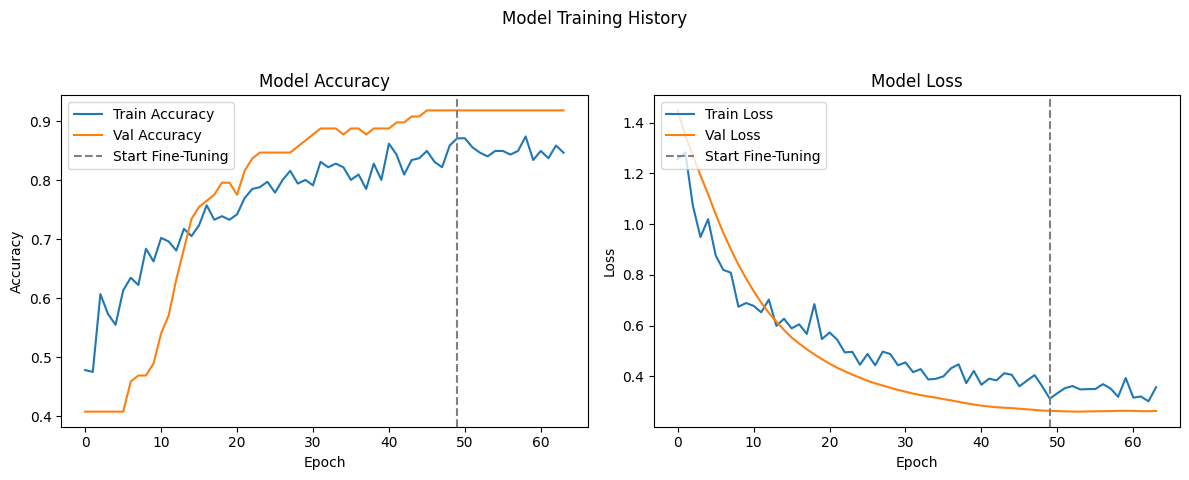


--- Final Evaluation on Test Set ---


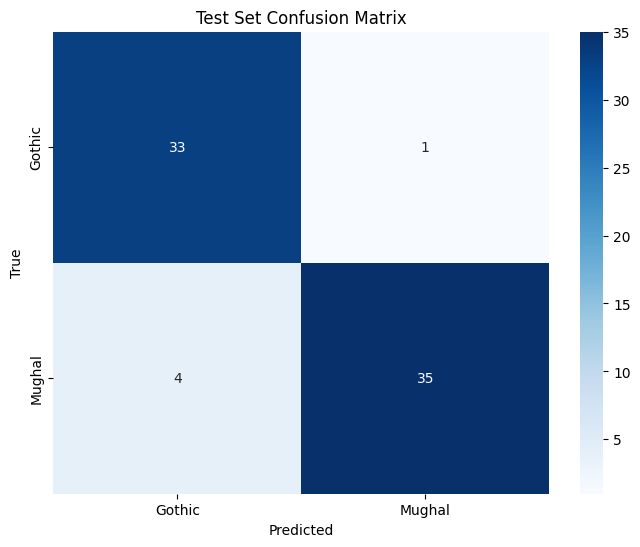


--- Test Set Classification Report ---
              precision    recall  f1-score   support

      Gothic       0.89      0.97      0.93        34
      Mughal       0.97      0.90      0.93        39

    accuracy                           0.93        73
   macro avg       0.93      0.93      0.93        73
weighted avg       0.93      0.93      0.93        73



In [2]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast
import os
import re
from glob import glob
from sklearn.model_selection import GroupShuffleSplit

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

IMG_SIZE = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
NUM_CLASSES = 2
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
FINE_TUNE_LR = 5e-6
EPOCHS = 50
FINE_TUNE_EPOCHS = 20
SEED = 123
DATA_DIR = "/content/drive/MyDrive/Binary Classification Dataset"

print("--- Loading Real Data (65:20:15 Split, Group-Stratified) ---")

def get_subject_id(filepath):
    try:
        filename_no_ext = os.path.splitext(os.path.basename(filepath))[0]
        match = re.match(r'([a-zA-Z0-9\-\.]{1,})[_|-]', filename_no_ext)

        if match:
            subject_id = match.group(1)
        else:
            subject_id = filename_no_ext

        class_name = os.path.basename(os.path.dirname(filepath))
        return f"{class_name}_{subject_id}"

    except Exception as e:
        print(f"Error parsing subject ID from {filepath}: {e}")
        return filepath

try:
    class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    print(f"Found class names: {class_names}")
    if len(class_names) != NUM_CLASSES:
        raise ValueError(f"Expected {NUM_CLASSES} classes, but found {len(class_names)} in {DATA_DIR}")
except FileNotFoundError:
    print(f"Error: Data directory not found at {DATA_DIR}")
    raise

class_to_index = {name: i for i, name in enumerate(class_names)}

all_filepaths = []
all_labels = []
all_groups = []

for class_name in class_names:
    class_dir = os.path.join(DATA_DIR, class_name)
    filepaths = glob(os.path.join(class_dir, "*.jpg")) + \
                glob(os.path.join(class_dir, "*.jpeg")) + \
                glob(os.path.join(class_dir, "*.png"))

    label_index = class_to_index[class_name]

    for fp in filepaths:
        all_filepaths.append(fp)
        all_labels.append(label_index)
        all_groups.append(get_subject_id(fp))

print(f"Total images found: {len(all_filepaths)}")
print(f"Total unique subjects found: {len(np.unique(all_groups))}")

all_filepaths_np = np.array(all_filepaths)
all_labels_np = np.array(all_labels)
all_groups_np = np.array(all_groups)

gss_train_temp = GroupShuffleSplit(n_splits=1, test_size=0.35, random_state=SEED)
train_idx, temp_idx = next(gss_train_temp.split(all_filepaths_np, all_labels_np, all_groups_np))

train_files, train_labels = all_filepaths_np[train_idx], all_labels_np[train_idx]
train_groups = all_groups_np[train_idx]
temp_files, temp_labels = all_filepaths_np[temp_idx], all_labels_np[temp_idx]
temp_groups = all_groups_np[temp_idx]
val_test_split_ratio = (0.15 / 0.35)
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=val_test_split_ratio, random_state=SEED)
val_idx_rel, test_idx_rel = next(gss_val_test.split(temp_files, temp_labels, temp_groups))

val_idx = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

val_files, val_labels = all_filepaths_np[val_idx], all_labels_np[val_idx]
test_files, test_labels = all_filepaths_np[test_idx], all_labels_np[test_idx]

train_subjects = set(train_groups)
val_subjects = set(all_groups_np[val_idx])
test_subjects = set(all_groups_np[test_idx])

print(f"Train samples: {len(train_files)}, Val samples: {len(val_files)}, Test samples: {len(test_files)}")
print(f"Train subjects: {len(train_subjects)}, Val subjects: {len(val_subjects)}, Test subjects: {len(test_subjects)}")
print(f"Val/Train subject overlap: {len(val_subjects.intersection(train_subjects))}")
print(f"Test/Train subject overlap: {len(test_subjects.intersection(train_subjects))}")
print(f"Test/Val subject overlap: {len(test_subjects.intersection(val_subjects))}")
if len(test_subjects.intersection(train_subjects)) > 0:
    print("WARNING: Subject leakage detected! Check your 'get_subject_id' function.")


def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)

    label_categorical = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label_categorical

def configure_dataset(files, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((list(files), list(labels)))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_data = configure_dataset(train_files, train_labels, shuffle=True)
val_data = configure_dataset(val_files, val_labels)
test_data = configure_dataset(test_files, test_labels)

print("Data loading and preparation complete.")
print(f"Train batches: {tf.data.experimental.cardinality(train_data)}")
print(f"Val batches:   {tf.data.experimental.cardinality(val_data)}")
print(f"Test batches:  {tf.data.experimental.cardinality(test_data)}")

def build_data_augmentation():
    return models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.1),
        RandomContrast(0.1),
    ], name="data_augmentation")


def build_optimized_model(input_shape, num_classes):
    data_augmentation = build_data_augmentation()

    base_model = MobileNetV3Small(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = base_model(x)

    x = layers.GlobalAveragePooling2D(name="global_pool")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5, name="head_dropout")(x)
    x = layers.Dense(64, activation='gelu', name="head_dense")(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name="classifier")(x)

    model = models.Model(inputs, outputs, name="Optimized_MobileNetV3Small")
    return model

model = build_optimized_model(INPUT_SHAPE, NUM_CLASSES)

model.compile(
    optimizer=AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Model Summary (Head Training) ---")
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=False),
]

print("\n--- Starting initial training of the head ---")
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

print("\n--- Unfreezing last block for fine-tuning ---")

base_model = model.get_layer('MobileNetV3Small')
base_model.trainable = True

fine_tune_from = 'expanded_conv_9'
found_layer = False

for layer in base_model.layers:
    if layer.name == fine_tune_from:
        found_layer = True
    if found_layer:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
        else:
            layer.trainable = False
    else:
        layer.trainable = False

print(f"Re-compiling model. Trainable weights: {len(model.trainable_weights)}")

model.compile(
    optimizer=AdamW(learning_rate=FINE_TUNE_LR, weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Starting fine-tuning ---")
last_epoch = 0
if 'epochs' in history.params:
    last_epoch = history.epoch[-1] + 1
elif len(history.history['loss']) > 0:
    last_epoch = len(history.history['loss'])
else:
    last_epoch = 0

print(f"Continuing from epoch {last_epoch}")

history_fine_tune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=last_epoch + FINE_TUNE_EPOCHS,
    initial_epoch=last_epoch,
    callbacks=callbacks,
    verbose=2
)

print("\n--- Training complete ---")

print("\n--- Generating plots and reports ---")

combined_history = {}
for key in history.history.keys():
    combined_history[key] = history.history[key] + history_fine_tune.history[key]

combined_history_df = pd.DataFrame(combined_history)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(combined_history_df['accuracy'], label='Train Accuracy')
plt.plot(combined_history_df['val_accuracy'], label='Val Accuracy')
plt.axvline(x=last_epoch-1, color='grey', linestyle='--', label='Start Fine-Tuning')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(combined_history_df['loss'], label='Train Loss')
plt.plot(combined_history_df['val_loss'], label='Val Loss')
plt.axvline(x=last_epoch-1, color='grey', linestyle='--', label='Start Fine-Tuning')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.suptitle('Model Training History')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Final Evaluation on Test Set ---")
y_pred_list = []
y_true_list = []

for images, labels in test_data:
    preds = model.predict_on_batch(images)
    y_pred_list.append(np.argmax(preds, axis=1))
    y_true_list.append(np.argmax(labels.numpy(), axis=1))

y_pred = np.concatenate(y_pred_list)
y_true = np.concatenate(y_true_list)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Set Confusion Matrix')
plt.show()

print("\n--- Test Set Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
import os
os.kill(os.getpid())

In [ ]:
import os
import numpy as np
import librosa
import tensorflow as tf
import soundfile as sf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Bidirectional, TimeDistributed, Input, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
DATASET_PATH = "/kaggle/input/torgo-audio/"

# Mapping folders to labels (Only M_Con and M_Dys)
LABELS = {
    "M_Con": 0,  # Male Control (Healthy)
    "M_Dys": 1,  # Male Dysarthric (Impaired)
    # "F_Con": 0,  # Female Control (Healthy)
    # "F_Dys": 1   # Female Dysarthric (Impaired)
}

In [ ]:
def is_valid_wav(file_path):
    try:
        with sf.SoundFile(file_path) as f:
            return True
    except Exception as e:
        print(e)  # Print error when file is unsupported
        return False  # File is corrupted or unsupported

# Function to Load and Convert Speech to Mel Spectrogram
def load_mel_spectrogram(file_path, n_mels=40, max_length=128):
    try:
        if not is_valid_wav(file_path):
            return None  # Unsupported file, already logged

        waveform, sr = librosa.load(file_path, sr=None)
        mel_spec = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Ensure consistent shape by padding or truncating
        if mel_spec_db.shape[1] < max_length:
            pad_width = max_length - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :max_length]

        return np.expand_dims(mel_spec_db, axis=-1)  # Shape: (n_mels, max_length, 1)
    except Exception as e:
        print(e)  # Print only the error message
        return None

# Load dataset
X1, y1 = [], []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if folder in LABELS and os.path.isdir(folder_path):  # Process only M_Con, M_Dys
        for speaker in os.listdir(folder_path):
            speaker_path = os.path.join(folder_path, speaker)
            for filename in os.listdir(speaker_path):
                if filename.endswith(".wav"):
                  file_path = os.path.join(speaker_path, filename)
                  mel_spec = load_mel_spectrogram(file_path)

                  if mel_spec is not None:  # Only add valid spectrograms
                        X1.append(mel_spec)
                        y1.append(LABELS[folder])

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/torgo-audio/'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Convert the list to a NumPy array for reshaping
X_array = np.array(X1)
X_flat = X_array.reshape(X_array.shape[0], -1)  # Flatten the spectrograms

# Perform PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

# Convert labels to a NumPy array
y_array = np.array(y1)

# Create a density plot
plt.figure(figsize=(8, 6))
sns.kdeplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_array, fill=True, alpha=0.6, palette='coolwarm')
# Scatter plot overlay (optional)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_array, cmap='coolwarm', alpha=0.3, edgecolors='k', marker="o")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Density Heatmap of Mel Spectrogram Data (PCA Reduced)")
plt.colorbar(label="Class (0: M_Con, 1: M_Dys)")
plt.show()

In [ ]:
# Convert to numpy arrays
X = np.array(X1)
y = np.array(y1)



print(f"Dataset Loaded: {X.shape}, Labels: {y.shape}")

In [ ]:
# Convert labels to categorical
y = to_categorical(y, num_classes=2)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

In [ ]:
input_shape = X_train.shape[1:]

input_layer = Input(shape=input_shape)

In [ ]:
input_shape = X_train.shape[1:]

input_layer = Input(shape=input_shape)

# CNN Layers with Dropout and Batch Normalization
x = Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)  # Normalize activations
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)  # Dropout to prevent overfitting

x = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)

# Reshape for LSTM
x = TimeDistributed(Flatten())(x)
# LSTM Layer with Dropout
x = Bidirectional(LSTM(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3))(x)

# Fully Connected Layer
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)  # Additional dropout

output_layer = Dense(2, activation='softmax')(x)

# Model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Summary
model.summary()

In [ ]:
# Train the model with Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(X_train, y_train, batch_size=16, epochs=30, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict class labels
y_pred_probs = model.predict(X_test)  # Get probability outputs
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot labels back to integers

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Convert to percentages
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
# Plot confusion matrix
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=['Healthy', 'Impaired'],
                 yticklabels=['Healthy', 'Impaired'], annot_kws={"size": 12})

# Add percentages slightly below the numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.7, f"{cm_percentage[i, j]:.1f}%",
                horizontalalignment='center', verticalalignment='center',
                color='black' if cm_percentage[i, j] < 50 else 'white', fontsize=10)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Percentage Scores")
plt.show()

After running the above cell, the Colab runtime will restart. Once it restarts, please run all your previous cells again from the beginning.